# Analysis: 20250613

In [1]:
!pip install nucleus-cdk==0.5.0rc2 | tail -n2

In [2]:
from cdk.analysis.cytosol import platereader as pr
import matplotlib.pyplot as plt
import warnings

# Filter warnings
warnings.filterwarnings('ignore')

# Initialize plotting
pr.plot_setup()

# Load the data

Provide a CSV file containing the data, and a platemap. This function returns both the data with the plate map mapped to it, and the platemap by itself, which is useful for certain tasks.

In [3]:
data, platemap = pr.load_platereader_data("./data/20250613-cytation3-pure-timecourse-gfp-EXPERIMENT-biotek-cdk.txt", "20250613-PPK Mg Opt platemap.csv")

# Basic Plots

## Kinetics 
Kinetic time traces of every well on the plate

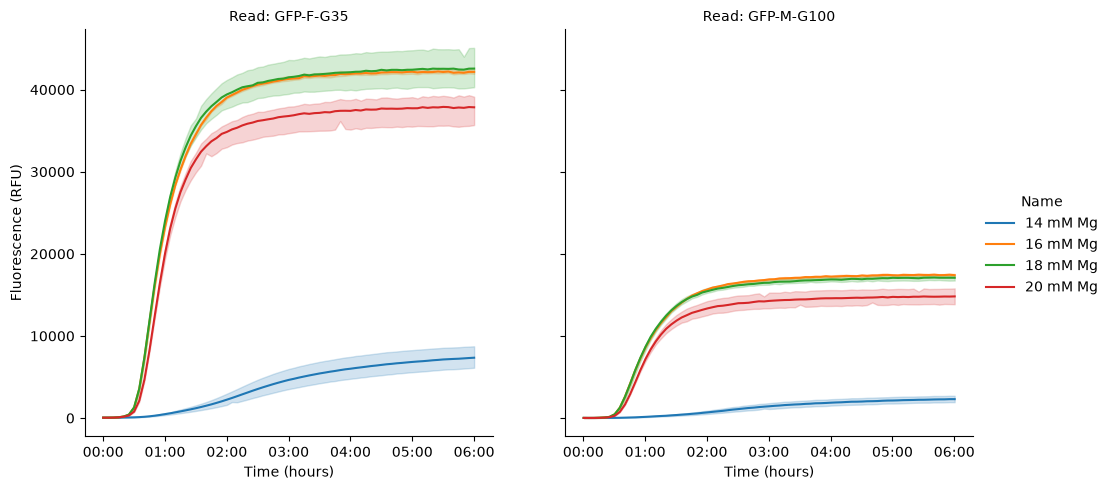

In [4]:
pr.plot_curves(data, col="Read");

## Steady state
Bar graph of steady-state endpoint of each sample. Steady state is calculated as the maximum fluorescence value over a 3-sample rolling average on the data.

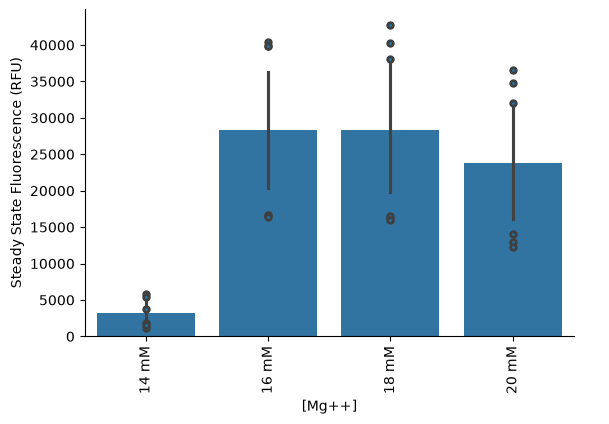

In [5]:
#| label: fig:endpoint-exp4

replace_dict = {'14 mM Mg':'14 mM',
                '16 mM Mg':'16 mM',
                '18 mM Mg':'18 mM',
                '20 mM Mg':'20 mM',
               }

data['Name'] = data['Name'].replace(replace_dict)

p = pr.plot_steadystate(data,)
plt.xlabel('[Mg++]')
p.savefig("plot7")

# Kinetics Analysis
These functions calculate key kinetic parameters of the time series.

PROVIDING AVERAGED KINETICS


(<seaborn.axisgrid.FacetGrid at 0x30eaef250>,
                                   Velocity                    \
                                       Time     Data      Max   
 Name  Read                                                     
 14 mM GFP-F-G35  0 days 02:27:31.480482987  2634.51  2130.61   
       GFP-M-G100 0 days 02:28:56.946844723   804.44   655.58   
 16 mM GFP-F-G35  0 days 00:55:26.576841297 21069.55 41134.12   
       GFP-M-G100 0 days 00:58:26.977193917  8727.69 15001.07   
 18 mM GFP-F-G35  0 days 00:54:34.015970580 21245.95 43667.18   
       GFP-M-G100 0 days 00:57:19.517360958  8552.65 15587.10   
 20 mM GFP-F-G35  0 days 00:57:21.823982158 18154.97 41730.75   
       GFP-M-G100 0 days 00:59:44.558463050  6888.90 15203.99   
 
                                        Lag                      Steady State  \
                                       Time    Data                      Time   
 Name  Read                                                                

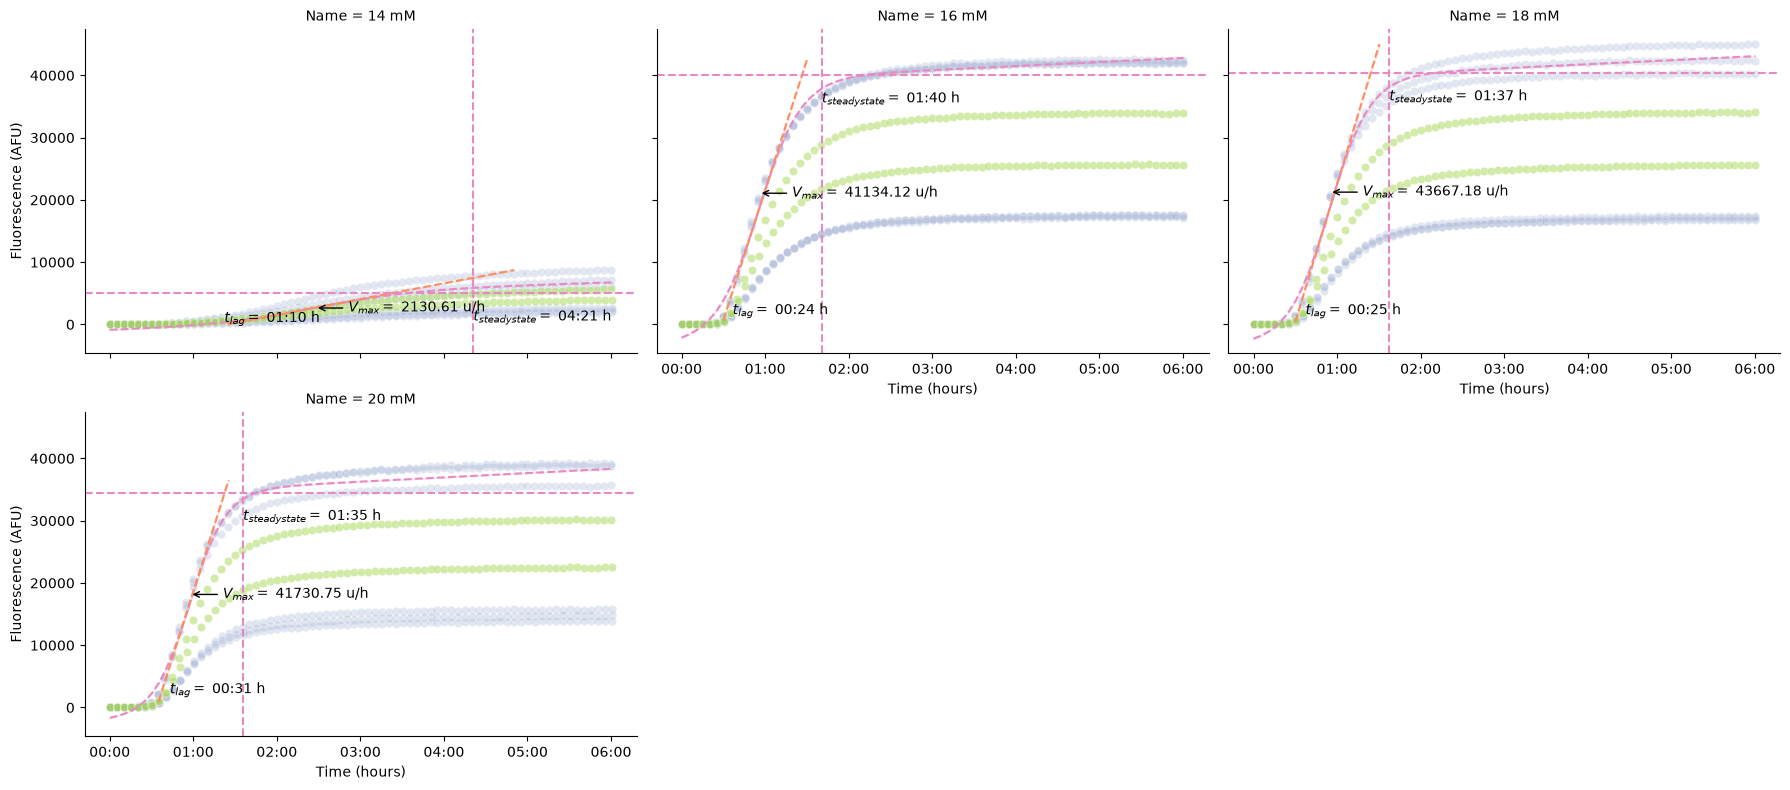

In [6]:
pr.plot_kinetics(data)

We can also calculate the kinetics and display the parameters as a table.

In [7]:
pr.kinetic_analysis(data)

Velocity                    \
                                           Time     Data      Max   
Name  Read       Well                                               
14 mM GFP-F-G35  I1   0 days 02:26:00.966849302  2002.08  1850.42   
                 I4   0 days 02:40:03.619734873  3056.78  1733.29   
                 I7   0 days 02:16:29.854864786  2844.68  2808.12   
16 mM GFP-F-G35  K1   0 days 00:56:03.381567036 21290.19 41127.89   
                 K4   0 days 00:55:26.823492393 20970.88 40914.52   
                 K7   0 days 00:54:49.525464463 20947.58 41359.94   
18 mM GFP-F-G35  M1   0 days 00:55:37.920332251 22495.91 44405.55   
                 M4   0 days 00:54:23.822306974 21196.44 43618.21   
                 M7   0 days 00:53:40.305272517 20045.49 42977.76   
20 mM GFP-F-G35  O1   0 days 00:57:46.375569039 19256.64 41226.56   
                 O4   0 days 00:57:29.222305056 18334.84 43159.90   
                 O7   0 days 00:56:49.874072380 16873.44 40805.81   
14 mM GFP-M-G100 I1   0 days 02:27:03.175983990   600.24   575.09   
                 I4   0 days 02:41:17.234366204   965.89   552.90   
                 I7   0 days 02:18:30.430183975   847.19   838.74   
16 mM GFP-M-G100 K1   0 days 00:59:02.219766468  8792.68 15048.69   
                 K4   0 days 00:58:35.285687911  8776.80 14918.69   
                 K7   0 days 00:57:43.426127372  8613.58 15035.82   
18 mM GFP-M-G100 M1   0 days 00:58:26.610633364  8546.00 15023.30   
                 M4   0 days 00:57:21.767889085  8723.57 15993.14   
                 M7   0 days 00:56:10.173560427  8388.38 15744.87   
20 mM GFP-M-G100 O1   0 days 01:00:39.672446515  7395.28 15881.76   
                 O4   0 days 00:59:36.683820488  6819.24 15154.78   
                 O7   0 days 00:58:57.319122147  6452.19 14575.42   

                                            Lag          \
                                           Time    Data   
Name  Read       Well                                     
14 mM GFP-F-G35  I1   0 days 01:21:05.918997679  988.37   
                 I4   0 days 00:54:14.786123569  352.42   
                 I7   0 days 01:15:42.982462454 1101.30   
16 mM GFP-F-G35  K1   0 days 00:24:59.811700442 2007.91   
                 K4   0 days 00:24:41.630388400 2093.51   
                 K7   0 days 00:24:26.232167433 2104.69   
18 mM GFP-F-G35  M1   0 days 00:25:14.155504233 1825.77   
                 M4   0 days 00:25:14.387841789 2067.46   
                 M7   0 days 00:25:41.209728772 2262.25   
20 mM GFP-F-G35  O1   0 days 00:29:44.840599008 2223.08   
                 O4   0 days 00:31:59.898864759 3068.56   
                 O7   0 days 00:32:01.253381488 2850.05   
14 mM GFP-M-G100 I1   0 days 01:24:25.751403763  326.79   
                 I4   0 days 00:56:28.231105506  117.85   
                 I7   0 days 01:17:54.159538711  353.07   
16 mM GFP-M-G100 K1   0 days 00:23:58.804581480  618.65   
                 K4   0 days 00:23:17.374543422  592.85   
                 K7   0 days 00:23:21.091499113  644.74   
18 mM GFP-M-G100 M1   0 days 00:24:18.752258919  494.72   
                 M4   0 days 00:24:38.121976314  676.31   
                 M7   0 days 00:24:12.205178798  675.47   
20 mM GFP-M-G100 O1   0 days 00:32:43.345355139 1165.77   
                 O4   0 days 00:32:36.782725909 1115.55   
                 O7   0 days 00:32:23.685899298 1059.26   

                                   Steady State           \
                                           Time     Data   
Name  Read       Well                                      
14 mM GFP-F-G35  I1   0 days 04:01:35.332208878  3803.95   
                 I4   0 days 05:15:50.496312268  5807.88   
                 I7   0 days 03:45:58.851490366  5404.90   
16 mM GFP-F-G35  K1   0 days 01:41:46.965444781 40451.37   
                 K4   0 days 01:40:43.352741553 39844.68   
                 K7   0 days 01:39:33.813390895 39800.41   
18 mM GFP-F-G35  M1   0 days 01:40:22.902